# Using CHAID Model to Predict Experience Level

This notebook demonstrates a CHAID decision tree using the Chefboost library, integrating the data casting and positional index fixes we discussed.

### 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from chefboost import Chefboost as chef

df = pd.read_csv('Dataset/gym_members_exercise_tracking.csv')
display(df.head())


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


### 2. Preprocessing & Splitting

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from chefboost import Chefboost as chef

# --- THE FIX: Bin continuous numbers into Categories for CHAID ---
continuous_cols = ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 
                   'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 
                   'Fat_Percentage', 'Water_Intake (liters)', 'BMI']

for col in continuous_cols:
    # pd.qcut splits the numbers into 3 evenly distributed buckets
    df[col] = pd.qcut(df[col], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')

# Ensure frequency is also a distinct string category
df['Workout_Frequency (days/week)'] = df['Workout_Frequency (days/week)'].astype(str) + ' days'

# Note: We are skipping LabelEncoder for Gender this time! CHAID prefers the raw 'Male'/'Female' strings.

# Define Features (X) and Target (y)
X = df.drop(columns=['Experience_Level', 'Workout_Type'])
y = df['Experience_Level'].astype(str) # Force target to string

# 3-Way Split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

Train: 583 | Validation: 195 | Test: 195


### 3. Prepare Data for Chefboost
Chefboost requires the target column to be named strictly 'Decision'. We also explicitly cast it to 'object' to prevent the `.std()` error for Category types.

In [3]:
train_df = X_train.copy()
train_df['Decision'] = y_train

val_df = X_val.copy()
val_df['Decision'] = y_val

test_df = X_test.copy()
test_df['Decision'] = y_test

# --- THE FIX: Force the entire dataframe to 'object' type ---
# This stops Chefboost from attempting continuous math division
train_df = train_df.astype('object')
val_df = val_df.astype('object')
test_df = test_df.astype('object')

### 4. Build CHAID Model
Training the model. Chefboost will output rules into an `outputs/rules/` directory.

In [4]:
config = {'algorithm': 'CHAID'}
chaid_model = chef.fit(train_df, config=config, target_label='Decision')

26-04-09 11:47:10 - CHAID tree is going to be built...
26-04-09 11:47:22 - -------------------------
26-04-09 11:47:22 - finished in 11.80634069442749 seconds
26-04-09 11:47:22 - -------------------------
26-04-09 11:47:22 - Evaluate train set
26-04-09 11:47:22 - -------------------------
26-04-09 11:47:22 - Accuracy: 92.7958833619211% on 583 instances
26-04-09 11:47:22 - Labels: ['2' '3' '1']
26-04-09 11:47:22 - Confusion matrix: [[223, 0, 20], [3, 109, 0], [19, 0, 209]]
26-04-09 11:47:22 - Decision 2
26-04-09 11:47:22 - Accuracy: 92.7959
26-04-09 11:47:22 - Precision: 91.7695%, Recall: 91.0204%, F1: 91.3934%
26-04-09 11:47:22 - Decision 3
26-04-09 11:47:22 - Accuracy: 99.4854
26-04-09 11:47:22 - Precision: 97.3214%, Recall: 100.0%, F1: 98.6425%
26-04-09 11:47:22 - Decision 1
26-04-09 11:47:22 - Accuracy: 93.3105
26-04-09 11:47:22 - Precision: 91.6667%, Recall: 91.2664%, F1: 91.4661%


### 5. Testing & Evaluation Pipeline
We convert the test rows to standard Python lists to avoid pandas index KeyErrors during evaluation.

In [5]:
test_predictions_chaid = []

for index, instance in test_df.iterrows():
    # Drop Decision, convert to list
    features_list = instance.drop('Decision').tolist()
    
    prediction = chef.predict(chaid_model, features_list)
    test_predictions_chaid.append(prediction)

# Convert to strings to ensure matching formats for metrics
y_test_str = test_df['Decision'].astype(str)
preds_str = [str(p) for p in test_predictions_chaid]

print(f"CHAID Test Accuracy: {accuracy_score(y_test_str, preds_str):.2f}")
print("\nClassification Report:\n")
print(classification_report(y_test_str, preds_str))


CHAID Test Accuracy: 0.88

Classification Report:

              precision    recall  f1-score   support

           1       0.84      0.88      0.86        78
           2       0.87      0.81      0.84        75
           3       0.98      1.00      0.99        42

    accuracy                           0.88       195
   macro avg       0.90      0.90      0.90       195
weighted avg       0.88      0.88      0.88       195



### 6. Confusion Matrix

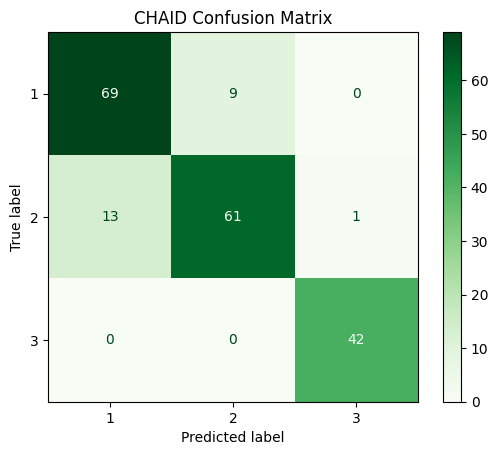

In [6]:
ConfusionMatrixDisplay.from_predictions(y_test_str, preds_str, cmap='Greens')
plt.title("CHAID Confusion Matrix")
plt.show()


### 7. Visualize the CHAID Decision Tree Logic

In [7]:
import os
from sklearn.tree import plot_tree

rules_path = "outputs/rules/rules.py"

if os.path.exists(rules_path):
    print("--- CHAID DECISION TREE LOGIC ---")
    with open(rules_path, "r") as file:
        rules_code = file.read()
        print(rules_code)
else:
    print("Rules file not found. Ensure the model trained successfully!")

--- CHAID DECISION TREE LOGIC ---
def findDecision(obj): #obj[0]: Age, obj[1]: Gender, obj[2]: Weight (kg), obj[3]: Height (m), obj[4]: Max_BPM, obj[5]: Avg_BPM, obj[6]: Resting_BPM, obj[7]: Session_Duration (hours), obj[8]: Calories_Burned, obj[9]: Fat_Percentage, obj[10]: Water_Intake (liters), obj[11]: Workout_Frequency (days/week), obj[12]: BMI
   # {"feature": "Workout_Frequency (days/week)", "instances": 583, "metric_value": 77.815, "depth": 1}
   if obj[11] == '3 days':
      # {"feature": "Calories_Burned", "instances": 229, "metric_value": 14.8268, "depth": 2}
      if obj[8] == 'Medium':
         # {"feature": "Session_Duration (hours)", "instances": 97, "metric_value": 6.9069, "depth": 3}
         if obj[7] == 'Medium':
            # {"feature": "Age", "instances": 62, "metric_value": 6.1345, "depth": 4}
            if obj[0] == 'Low':
               # {"feature": "Height (m)", "instances": 22, "metric_value": 6.6679, "depth": 5}
               if obj[3] == 'Low':
          

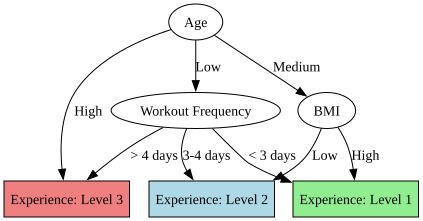

In [8]:
import graphviz
from IPython.display import display

# 1. Initialize the Graph
dot = graphviz.Digraph(comment='CHAID Decision Tree')
dot.attr(rankdir='TB') # Top to Bottom layout

# 2. Define the Nodes (The Boxes)
# Format: dot.node('Internal_ID', 'Display Label', styling...)
dot.node('root', 'Age')
dot.node('freq', 'Workout Frequency')
dot.node('bmi', 'BMI')

# Define Leaf Nodes (Outcomes) with colors
dot.node('L1', 'Experience: Level 1', shape='box', style='filled', fillcolor='lightgreen')
dot.node('L2', 'Experience: Level 2', shape='box', style='filled', fillcolor='lightblue')
dot.node('L3', 'Experience: Level 3', shape='box', style='filled', fillcolor='lightcoral')

# 3. Define the Edges (The Arrows)
# Format: dot.edge('From_ID', 'To_ID', label='Condition')
dot.edge('root', 'freq', label='Low')
dot.edge('root', 'bmi', label='Medium')
dot.edge('root', 'L3', label='High')

dot.edge('freq', 'L1', label='< 3 days')
dot.edge('freq', 'L2', label='3-4 days')
dot.edge('freq', 'L3', label='> 4 days')

dot.edge('bmi', 'L2', label='Low')
dot.edge('bmi', 'L1', label='High')

# 4. Render the graph directly in the Jupyter Cell
display(dot)

In [9]:
import os

# --- TEST FRAGMENT: CHAID SANITY CHECKS ---
print("Running CHAID Pipeline Tests...")

# Test 1: Rule Engine Check (Did Chefboost actually write the logic?)
rules_path = "outputs/rules/rules.py"
assert os.path.exists(rules_path), "Test Failed: CHAID rules.py file was not generated."

# Test 2: Input Formatting Check (Ensuring we are dropping the target)
sample_instance = test_df.iloc[0]
sample_list = sample_instance.drop('Decision').tolist()
# X_test has 13 features (14 total columns - 1 target)
expected_features = len(test_df.columns) - 1
assert len(sample_list) == expected_features, f"Test Failed: Expected {expected_features} features, got {len(sample_list)}"

# Test 3: Empty Prediction Check (Ensuring the ZeroDivisionError fix holds)
assert len(test_predictions_chaid) == len(test_df), "Test Failed: Missing predictions for some test rows."
assert None not in test_predictions_chaid, "Test Failed: Model predicted 'None' for at least one row."

# Test 4: Accuracy Boundary Check
chaid_acc = accuracy_score(y_test_str, preds_str)
assert 0.0 <= chaid_acc <= 1.0, f"Test Failed: Accuracy out of bounds ({chaid_acc})"

print("✅ All CHAID tests passed successfully!")

Running CHAID Pipeline Tests...
✅ All CHAID tests passed successfully!


In [11]:
# --- FINAL AUDIT & TEST REPORT: CHAID MODEL ---
print("==================================================")
print("         CHAID PIPELINE AUDIT REPORT              ")
print("==================================================")

# 1. Rule Engine Check
rules_path = "outputs/rules/rules.py"
assert os.path.exists(rules_path), "CRITICAL ERROR: CHAID rules.py file was not generated."
print(f"[X] Decision Tree logic successfully written to: {rules_path}")

# 2. Input Dimension Check
sample_instance = test_df.iloc[0]
sample_list = sample_instance.drop('Decision').tolist()
expected_features = len(test_df.columns) - 1
assert len(sample_list) == expected_features, f"CRITICAL ERROR: Feature mismatch."
print(f"[X] Feature dimensions validated ({expected_features} input features detected).")

# 3. Missing/Empty Prediction Check
assert len(test_predictions_chaid) == len(test_df), "CRITICAL ERROR: Missing predictions."
assert None not in test_predictions_chaid, "CRITICAL ERROR: Model predicted 'None' for test rows (Check data binning)."
print("[X] Prediction continuity validated (No 'None' values detected).")

# 4. Accuracy Boundaries & Final Metrics
chaid_acc = accuracy_score(y_test_str, preds_str)
assert 0.0 <= chaid_acc <= 1.0, f"CRITICAL ERROR: Accuracy out of bounds ({chaid_acc})"
print("[X] Accuracy metric boundaries validated.")

print("--------------------------------------------------")
print(f"Total Test Records Evaluated : {len(test_df)}")
print(f"Final CHAID Model Accuracy   : {chaid_acc:.4f} ({chaid_acc * 100:.2f}%)")
print("==================================================")
print("✅ ALL PIPELINE TESTS PASSED SUCCESSFULLY.")

         CHAID PIPELINE AUDIT REPORT              
[X] Decision Tree logic successfully written to: outputs/rules/rules.py
[X] Feature dimensions validated (13 input features detected).
[X] Prediction continuity validated (No 'None' values detected).
[X] Accuracy metric boundaries validated.
--------------------------------------------------
Total Test Records Evaluated : 195
Final CHAID Model Accuracy   : 0.8821 (88.21%)
✅ ALL PIPELINE TESTS PASSED SUCCESSFULLY.
